cluster_label
Cluster 0    99695
Cluster 1    40183
Cluster 3    39890
Cluster 2    20232
Name: count, dtype: int64
  cluster_label  similarity_score
0     Cluster 0          0.447201
1     Cluster 1          0.742350
2     Cluster 2          1.000000
3     Cluster 3          0.753322


C:\Users\jithe\AppData\Local\Temp\ipykernel_7148\2091601425.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=ax)


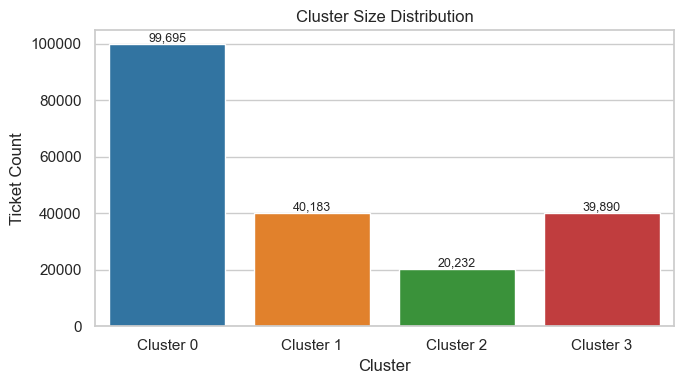

C:\Users\jithe\AppData\Local\Temp\ipykernel_7148\2091601425.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_sim, x='cluster_label', y='similarity_score', palette=PALETTE, ax=ax)


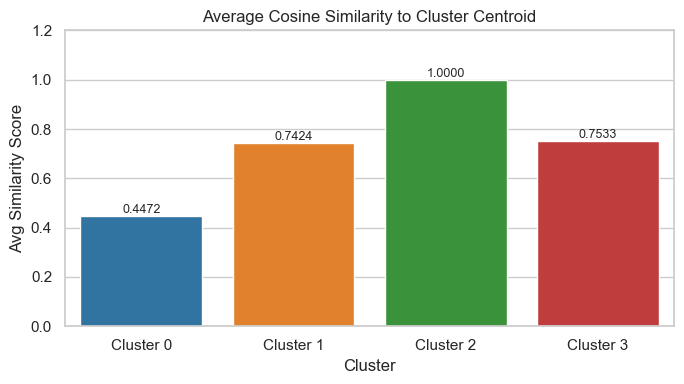

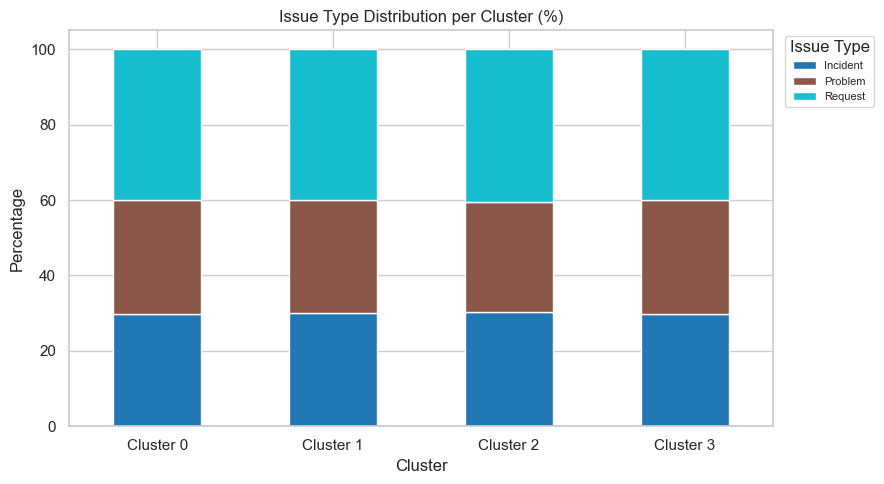

C:\Users\jithe\AppData\Local\Temp\ipykernel_7148\2091601425.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster_label', y='resolution_time_hours',


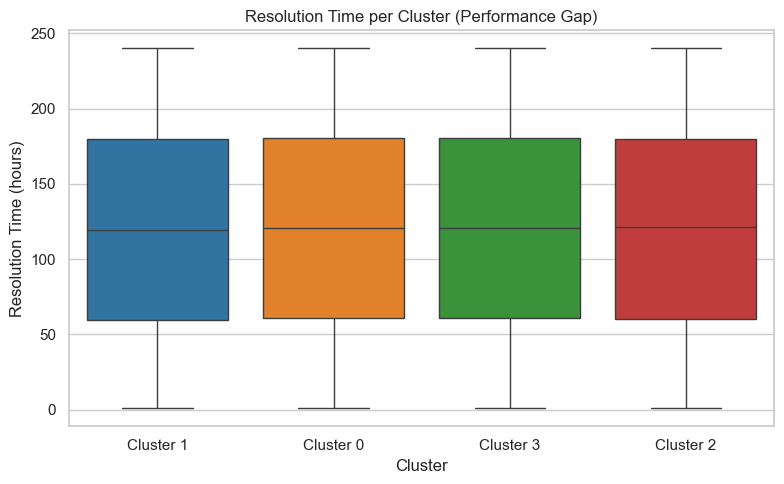

C:\Users\jithe\AppData\Local\Temp\ipykernel_7148\2091601425.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster_label', y='customer_satisfaction_score',


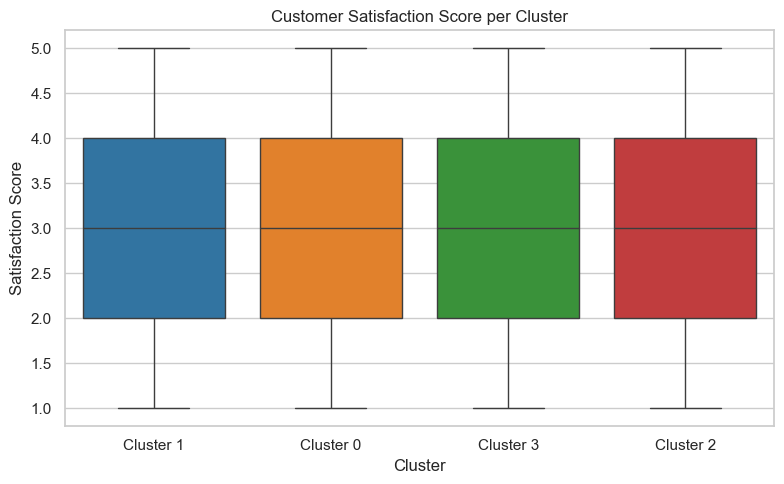

Saved clustered_tickets.csv: (200000, 36)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

os.makedirs('images/M4', exist_ok=True)
sns.set_theme(style='whitegrid')
PALETTE = 'tab10'
N_CLUSTERS = 4
df = pd.read_csv('cleaned_customer_support_tickets_200k.csv')
df['issue_description'] = df['issue_description'].fillna('')

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X = tfidf.fit_transform(df['issue_description'])

# KMeans clustering into 4 clusters
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X)
df['cluster_label'] = df['cluster'].map(lambda c: f'Cluster {c}')

print(df['cluster_label'].value_counts())

# Sample 5000 rows for similarity computation (memory-safe)
sample = df.sample(5000, random_state=42).copy()
X_sample = tfidf.transform(sample['issue_description'])

# Cosine similarity of each doc to its cluster centroid
centroids = km.cluster_centers_
sim_scores = []
for i, row in enumerate(X_sample):
    c = sample.iloc[i]['cluster']
    score = cosine_similarity(row, centroids[c].reshape(1, -1))[0][0]
    sim_scores.append(score)

sample['similarity_score'] = sim_scores

# Merge similarity scores back to full df (NaN for non-sampled rows)
df = df.merge(sample[['ticket_id', 'similarity_score']], on='ticket_id', how='left')

avg_sim = sample.groupby('cluster_label')['similarity_score'].mean().reset_index()
print(avg_sim)

fig, ax = plt.subplots(figsize=(7, 4))
counts = df['cluster_label'].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=ax)
ax.set_title('Cluster Size Distribution')
ax.set_xlabel('Cluster'); ax.set_ylabel('Ticket Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('images/M4/plot1_cluster_size.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=avg_sim, x='cluster_label', y='similarity_score', palette=PALETTE, ax=ax)
ax.set_title('Average Cosine Similarity to Cluster Centroid')
ax.set_xlabel('Cluster'); ax.set_ylabel('Avg Similarity Score')
ax.set_ylim(0, avg_sim['similarity_score'].max() * 1.2)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('images/M4/plot2_avg_similarity.png', dpi=150)
plt.show()

ct = df.groupby(['cluster_label', 'type']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct_pct.plot(kind='bar', stacked=True, colormap='tab10', ax=ax)
ax.set_title('Issue Type Distribution per Cluster (%)')
ax.set_xlabel('Cluster'); ax.set_ylabel('Percentage')
ax.legend(title='Issue Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/M4/plot3_cluster_issue_type.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='cluster_label', y='resolution_time_hours',
            palette=PALETTE, showfliers=False, ax=ax)
ax.set_title('Resolution Time per Cluster (Performance Gap)')
ax.set_xlabel('Cluster'); ax.set_ylabel('Resolution Time (hours)')
plt.tight_layout()
plt.savefig('images/M4/plot4_resolution_time_boxplot.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='cluster_label', y='customer_satisfaction_score',
            palette=PALETTE, ax=ax)
ax.set_title('Customer Satisfaction Score per Cluster')
ax.set_xlabel('Cluster'); ax.set_ylabel('Satisfaction Score')
plt.tight_layout()
plt.savefig('images/M4/plot5_satisfaction_boxplot.png', dpi=150)
plt.show()

# ---------------------------------------------------
# Save the clustered + scored dataset for Module 6
# ---------------------------------------------------
df.to_csv('clustered_tickets.csv', index=False)
print('Saved clustered_tickets.csv:', df.shape) 